In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
import nitools as nt


# get vs from cerebellum SUIT atlas

In [2]:
atlas_suit,_= am.get_atlas(atlas_str='SUIT3')
prob_parcel_dir = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(prob_parcel_dir):
    prob_parcel_dir = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
# load model pkl
with open(f'{prob_parcel_dir}/mdtb-s1_mdtb-s2_fusion_k4_SUIT3.pkl', 'rb') as f:
    full_model = pickle.load(f)

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


In [3]:
# group = full_model.arrange.logpi
# group_prob = pt.softmax(group,dim=0)
# group_prob = group_prob.reshape(1,-1,group_prob.shape[-1])


# group_vol = get_volumes(group_prob.cpu().numpy(),atlas_name='SUIT3')
# flatmap.plot_multi_flat(group_vol,
#                          grid=(6,5),colorbar= False,
#                         cmap='Set1' ,dtype='prob',
#                         space = 'SUIT',
#                         render='matplotlib',
#                         titles=np.arange(1,2),
#                         bordersize = 0.5,
#                         fig_size = (20,20))

# Load training and testing data

In [4]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'

cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

In [5]:
  # Load surface files for left and right hemispheres
surfs = [f"{base_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig


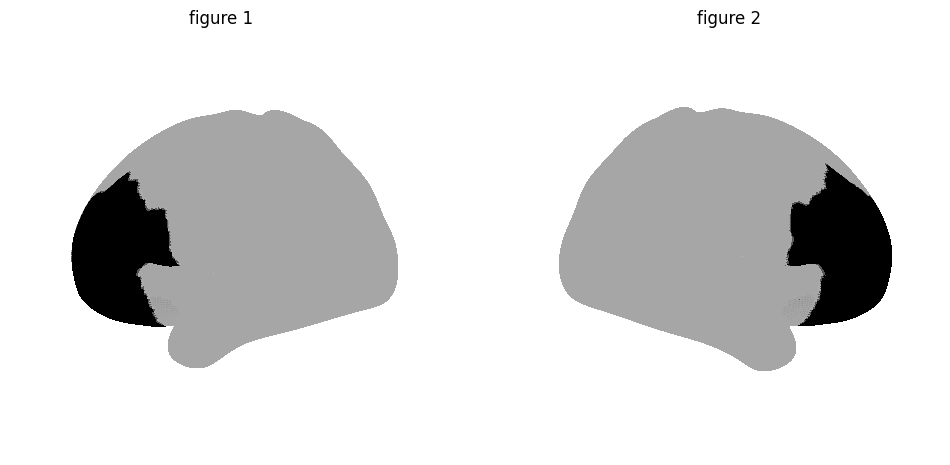

In [6]:
# roi
ROI_cortex = [32,12,14,18,19,20,27] # only used if space is fs32k
atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
model_name_L = f'{cort_dir}/Desikan.32k.L.label.gii'
model_name_R = f'{cort_dir}/Desikan.32k.R.label.gii'

yeo_parcels = atlas.read_data([model_name_L,model_name_R])
ROI_mask = np.isin(yeo_parcels, ROI_cortex).astype(int)


mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()


In [7]:
# find indices where mask is 1 
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

8171

In [8]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [9]:
# original_list = [7,12 ,16, 17, 18, 19,22]
original_list = list(np.arange(0, 29, 1))
# print(original_list)

extended_list = original_list.copy() 
increment = 29   
runs = 15  

for i in range(1, runs + 1):
    extended_list.extend([x + i * increment for x in original_list])

print(len(original_list))
print(len(extended_list))
print(np.max(np.array(extended_list)))


data_mdtb_s1_run_l = data_mdtb_s1_run[:,extended_list,:]
data_mdtb_s1_all_l = data_mdtb_s1_all[:,original_list,:]

29
464
463


parcel1:Unsure -- parcel2:Motor -- parcel3:socio-linguistic -- parcel4:Multiple demand

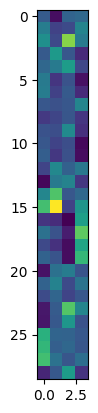

In [10]:
VLib = VL_mdtb_1[original_list,:]
plt.imshow(VLib)

In [11]:
vtest =  VL_mdtb_2
vtest.shape

(32, 4)

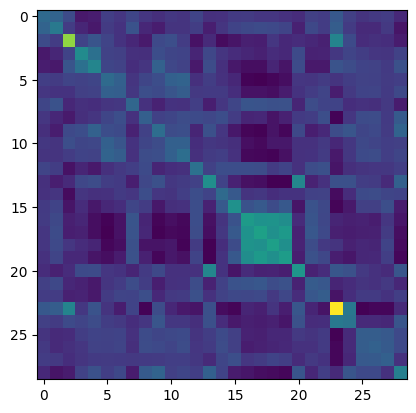

In [12]:
cond_vec = np.tile(np.arange(1, len(original_list) + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), len(original_list))

Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run_l[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

plt.imshow(G_individuals_averaged)

run evaluation on U_hats estimated using HBP framework - data only

In [13]:
D = ut.build_combinations(G_individuals_averaged, strategy='random',n_iter=200,n_tasks=3,seed=144,replacement=False)
len(D)

197

In [14]:
D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all_l,VLib,data_mdtb_s2_all, vtest,ROI_indices)


Processing combination: 0
Processing combination: 100


<Axes: xlabel='log_det_mc', ylabel='cos'>

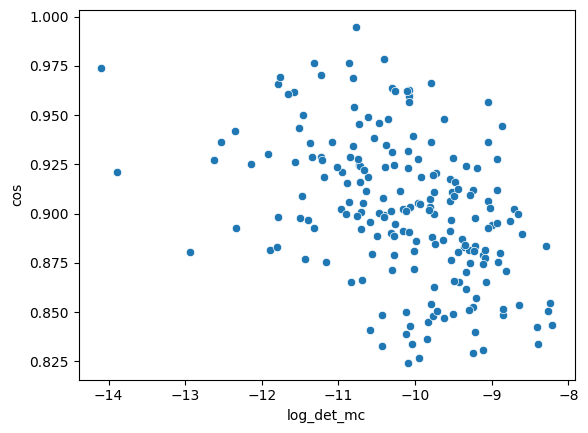

In [20]:
sns.scatterplot(data=D_ev, x='log_det_mc', y='cos')


<Axes: xlabel='variance_mc', ylabel='cos'>

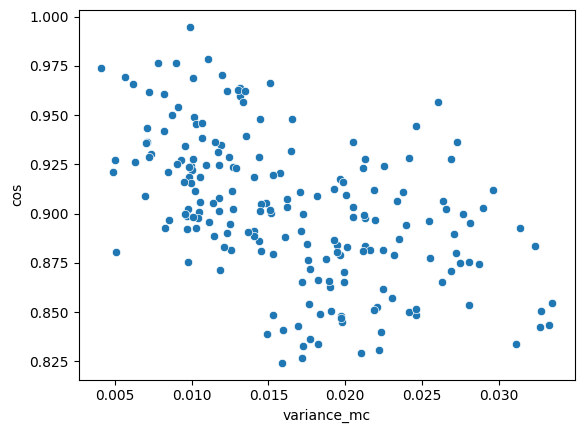

In [21]:
sns.scatterplot(data=D_ev, x='variance_mc', y='cos')


<Axes: xlabel='inverse_trace_mc', ylabel='cos'>

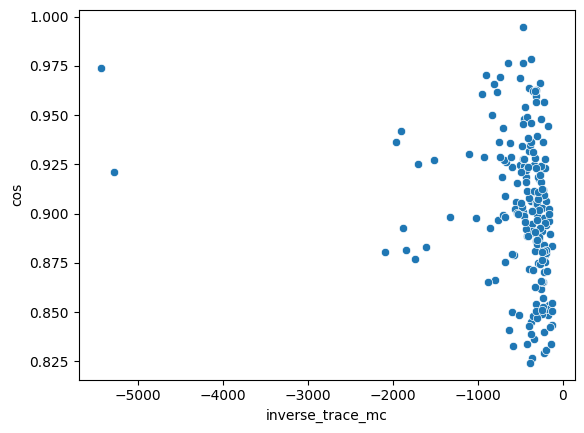

In [22]:
sns.scatterplot(data=D_ev, x='inverse_trace_mc', y='cos')


In [23]:
corr_1 = np.corrcoef(D_ev['log_det_mc'],D_ev['cos'])[0,1]
print(corr_1)
corr_2 = np.corrcoef(D_ev['variance_mc'],D_ev['cos'])[0,1]
print(corr_2)
corr_3 = np.corrcoef(D_ev['inverse_trace_mc'],D_ev['cos'])[0,1]
print(corr_3)

-0.429795825042945
-0.5087105377095043
-0.21228084189213445
